In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

In [2]:
from src.preprocessing.dataset_loader import (
    build_dataset_index
)

train_paths, train_labels = build_dataset_index(
    "../data/raw/train"
)

test_paths, test_labels = build_dataset_index(
    "../data/raw/test"
)

In [3]:
from src.preprocessing.splitter import (
    create_stratified_split
)

(
    X_train,
    X_val,
    y_train,
    y_val
) = create_stratified_split(
    train_paths,
    train_labels
)

In [4]:
from src.preprocessing.dataloaders import (
    create_datasets
)

(
    train_dataset,
    val_dataset,
    test_dataset
) = create_datasets(
    X_train,
    y_train,
    X_val,
    y_val,
    test_paths,
    test_labels
)

In [5]:
from src.preprocessing.dataloaders import (
    create_dataloaders
)

(
    train_loader,
    val_loader,
    test_loader
) = create_dataloaders(
    train_dataset,
    val_dataset,
    test_dataset,
    batch_size=32
)

In [6]:
images, labels = next(
    iter(train_loader)
)

print(images.shape)
print(labels.shape)

c:\Users\gagan\Desktop\Federated Learning\federated-xray-classification\venv\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([32, 3, 224, 224])
torch.Size([32])


In [7]:
print(labels)

tensor([1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 0, 1, 1])


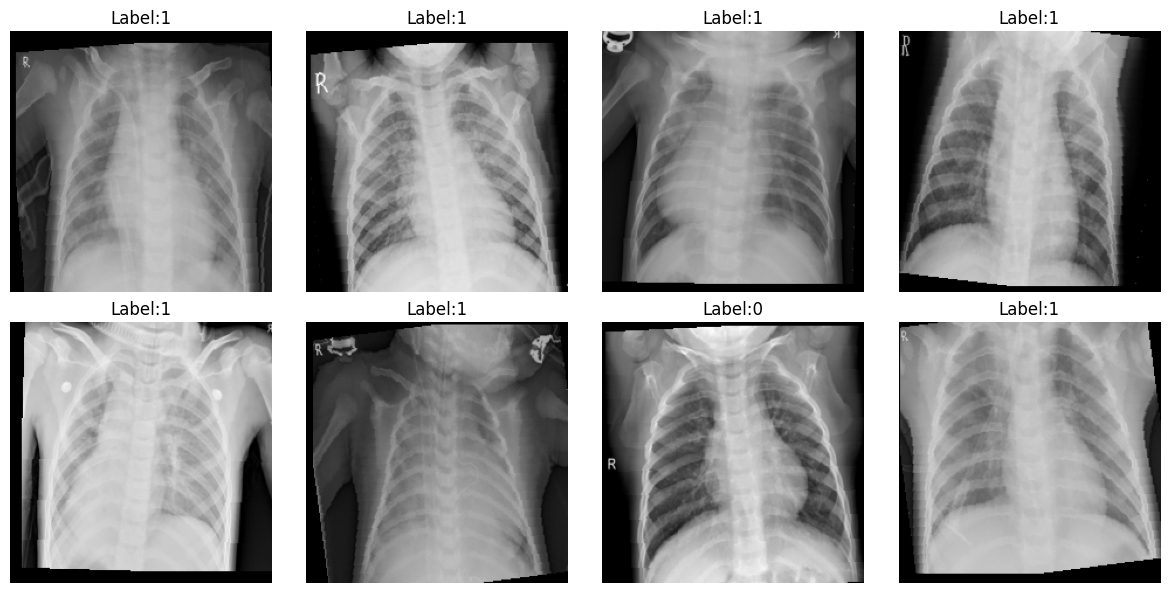

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2,
    4,
    figsize=(12,6)
)

for i in range(8):

    image = images[i]

    image = image.permute(
        1,
        2,
        0
    )

    image = (
        image * 0.5
    ) + 0.5

    ax = axes[i//4, i%4]

    ax.imshow(
        image.numpy()
    )

    ax.set_title(
        f"Label:{labels[i].item()}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
print("="*40)

print(
    "Train Dataset:",
    len(train_dataset)
)

print(
    "Validation Dataset:",
    len(val_dataset)
)

print(
    "Test Dataset:",
    len(test_dataset)
)

print("="*40)

Train Dataset: 4172
Validation Dataset: 1044
Test Dataset: 624


In [13]:
import json
import os

os.makedirs(
    "../configs",
    exist_ok=True
)

In [14]:
config = {

    "image_size": 224,

    "batch_size": 32,

    "train_samples":
        len(train_dataset),

    "validation_samples":
        len(val_dataset),

    "test_samples":
        len(test_dataset)
}

In [15]:
with open(
    "../configs/preprocessing_config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )